In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from scipy.stats import shapiro, probplot
from scipy.stats import ks_2samp
# from scipy.stats import gamma, kstest
from scipy.optimize import fsolve
from scipy.special import gamma
from scipy.stats import weibull_min
import pandas as pd
import scipy.stats as st



In [3]:

df = pd.read_csv('diabetes.csv')
# удаление дубликатов
df_unique = df.drop_duplicates()

In [4]:
df_type1 = df_unique[df_unique['Insulin'] == 0]
df_type2 = df_unique[df_unique['Insulin'] != 0]


In [5]:
def z_filter(data, columns, alpha = 2):
    result = data.copy()
    for column in columns:
        result = result[abs((result[column] - result[column].mean())/result[column].std()) < alpha]
    return result

df_type1 = z_filter(df_type1, ['SkinThickness', 'Glucose', 'Pregnancies', 'BMI', 'Age'], alpha = 3)
df_type2 = z_filter(df_type2, ['SkinThickness', 'Glucose', 'Pregnancies', 'BMI', 'Age'], alpha = 3)

In [6]:
df_type1_sorted = df_type1.sort_values(by='Glucose').reset_index(drop=True)
df_type2_sorted = df_type2.sort_values(by='Glucose').reset_index(drop=True)


In [7]:
print(len(df_type1))
print(len(df_type2))
print(len(df_type1_sorted))
print(len(df_type2_sorted))

359
380
359
380


In [8]:
print(df_type1_sorted.head())

print(df_type2_sorted.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            5       44             62              0        0  25.0   
1            9       57             80             37        0  32.8   
2            0       57             60              0        0  21.7   
3            3       61             82             28        0  34.4   
4            7       62             78              0        0  32.6   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.587   36        0  
1                     0.096   41        0  
2                     0.735   67        0  
3                     0.243   46        0  
4                     0.391   41        0  
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            2       56             56             28       45  24.2   
1            2       68             62             13       15  20.1   
2            2       68             70             32       66  25.0   
3           10 

In [9]:
train_type1 = df_type1_sorted.iloc[::2]
test_type1 = df_type1_sorted.iloc[1::2]

train_type2 = df_type2_sorted.iloc[::2]
test_type2 = df_type2_sorted.iloc[1::2]

In [10]:
print(len(train_type1))
print(len(test_type1))

print(len(train_type2))
print(len(test_type2))



180
179
190
190


In [11]:
print(train_type1.head())
print(test_type1.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            5       44             62              0        0  25.0   
2            0       57             60              0        0  21.7   
4            7       62             78              0        0  32.6   
6            0       67             76              0        0  45.3   
8            2       71             70             27        0  28.0   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.587   36        0  
2                     0.735   67        0  
4                     0.391   41        0  
6                     0.194   46        0  
8                     0.586   22        0  
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
1            9       57             80             37        0  32.8   
3            3       61             82             28        0  34.4   
5            8       65             72             23        0  32.0   
7            1 

In [12]:
print(train_type2.head())
print(test_type2.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            2       56             56             28       45  24.2   
2            2       68             70             32       66  25.0   
4            1       71             48             18       76  20.4   
6            3       74             68             28       45  29.7   
8            8       74             70             40       49  35.3   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.332   22        0  
2                     0.187   25        0  
4                     0.323   22        0  
6                     0.293   23        0  
8                     0.705   39        0  
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
1            2       68             62             13       15  20.1   
3           10       68            106             23       49  35.5   
5            1       71             78             50       45  33.2   
7            0 

In [27]:
def analyze_glucose_distribution(data, title=""):
    data = data.dropna()
    
    plt.figure(figsize=(6,4))
    sns.histplot(data, kde=True)
    plt.title(f"{title}: Гистограмма Glucose")
    plt.show()

    plt.figure(figsize=(6,4))
    probplot(data, dist="norm", plot=plt)
    plt.title(f"{title}: Q-Q Plot")
    plt.show()
    
    stat, p_value = shapiro(data)
    print(f"{title}: Shapiro-Wilk p-value = {p_value:.5f}")
    if p_value < 0.05:
        print("   Гипотеза о нормальности отклоняется (p < 0.05).")
    else:
        print("   Нет оснований отвергнуть нормальность (p >= 0.05).")


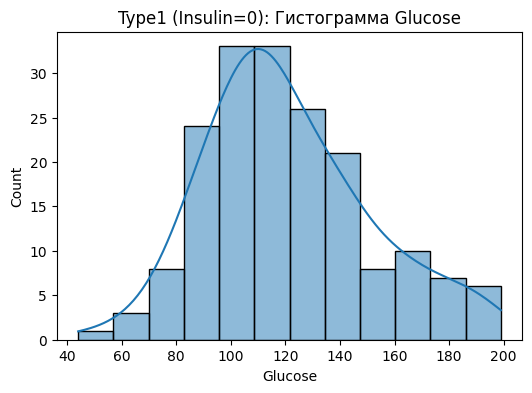

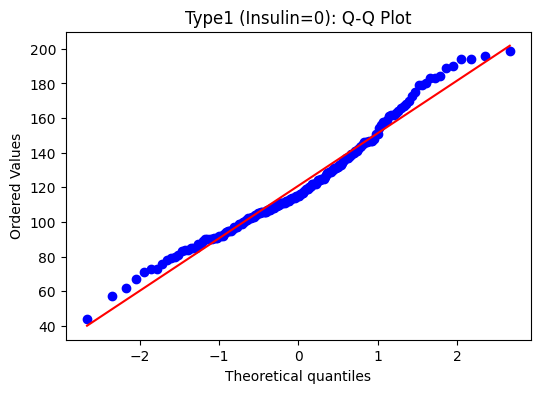

Type1 (Insulin=0): Shapiro-Wilk p-value = 0.00237
   Гипотеза о нормальности отклоняется (p < 0.05).


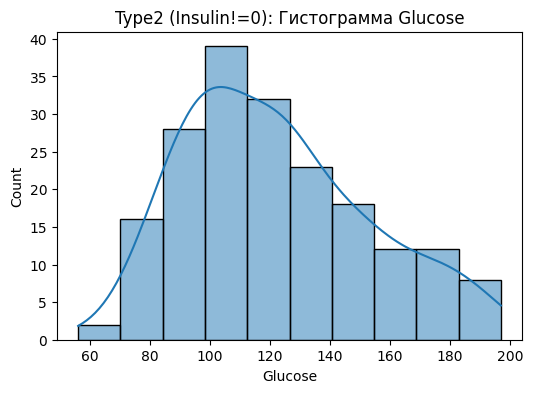

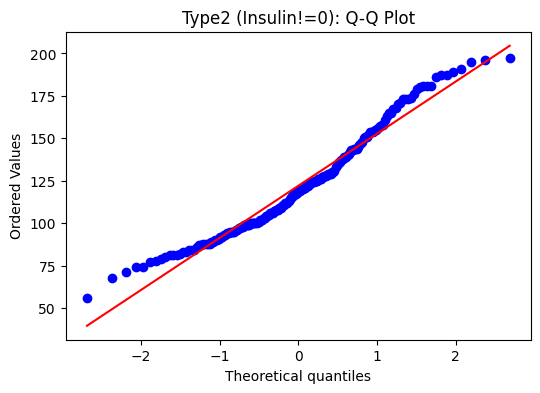

Type2 (Insulin!=0): Shapiro-Wilk p-value = 0.00010
   Гипотеза о нормальности отклоняется (p < 0.05).


In [28]:
analyze_glucose_distribution(train_type1['Glucose'], "Type1 (Insulin=0)")
analyze_glucose_distribution(train_type2['Glucose'], "Type2 (Insulin!=0)")

In [99]:
def get_best_distribution(data):
    dist_names = ["norm", "gamma", "exponweib", "weibull_max", "weibull_min", "pareto", "genextreme"]
    dist_results = []
    params = {}
    for dist_name in dist_names:
        dist = getattr(st, dist_name)
        param = dist.fit(data)

        params[dist_name] = param
        D, p = st.kstest(data, dist_name, args=param)
        print("p value for "+dist_name+" = "+str(p))
        dist_results.append((dist_name, p))

    best_dist, best_p = (max(dist_results, key=lambda item: item[1]))

    print("Best fitting distribution: "+str(best_dist))
    print("Best p value: "+ str(best_p))
    print("Parameters for the best fit: "+ str(params[best_dist]))
    
    return best_dist, best_p, params[best_dist]


In [100]:
get_best_distribution(train_type1['Glucose'])
get_best_distribution(train_type2['Glucose'])


p value for norm = 0.15852314048084826
p value for gamma = 0.6660623736629536
p value for exponweib = 0.7479312012782391
p value for weibull_max = 2.1801384623612094e-109
p value for weibull_min = 0.5402325251197855
p value for pareto = 2.429590375213192e-18
p value for genextreme = 0.7169809514546921
Best fitting distribution: exponweib
Best p value: 0.7479312012782391
Parameters for the best fit: (np.float64(95.21099554888269), np.float64(3.8453003063569415), np.float64(-366.7524911471601), np.float64(320.3468703340193))
p value for norm = 0.16674918934969662
p value for gamma = 0.8251000867327545
p value for exponweib = 9.496771924428449e-123
p value for weibull_max = 8.635415072427449e-113
p value for weibull_min = 0.8815283356770682
p value for pareto = 3.880293379933047e-13
p value for genextreme = 0.7176303195117459
Best fitting distribution: weibull_min
Best p value: 0.8815283356770682
Parameters for the best fit: (np.float64(1.9144921323822626), np.float64(66.30246756007963), 

('weibull_min',
 np.float64(0.8815283356770682),
 (np.float64(1.9144921323822626),
  np.float64(66.30246756007963),
  np.float64(63.20979616406201)))

In [29]:
def estimate_weibull_params_moments(data):
    # data = data[data > 0].dropna()
    x_mean = data.mean()
    x_var = data.var(ddof=1)
    
    def equations(k):
        lam = x_mean / gamma(1 + 1.0/k)
        theor_var = lam**2 * (gamma(1 + 2.0/k) - gamma(1 + 1.0/k)**2)
        return x_var - theor_var  
    
    
    k_initial_guess = 1.0  
    k_solution, = fsolve(equations, x0=k_initial_guess)
    
    lam_solution = x_mean / gamma(1 + 1.0/k_solution)
    
    return k_solution, lam_solution

In [30]:
k1, lam1 = estimate_weibull_params_moments(train_type1['Glucose'])
k2, lam2 = estimate_weibull_params_moments(train_type2['Glucose'])
print("Weibull для Type1: k =", k1, ", lambda =", lam1)
print("Weibull для Type2: k =", k2, ", lambda =", lam2)

Weibull для Type1: k = 4.51274998540023 , lambda = 132.48510504549162
Weibull для Type2: k = 4.473182083911807 , lambda = 133.82660060463738


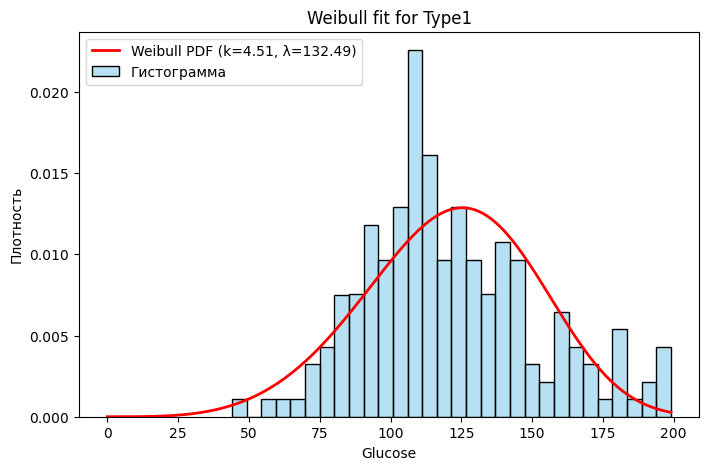

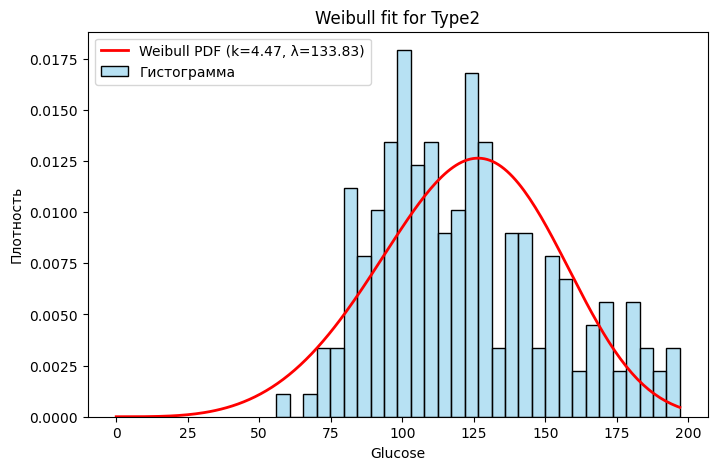

In [31]:
def plot_weibull_fit(data, k, lam, title):
    # data = data[data > 0].dropna()
    
    plt.figure(figsize=(8, 5))
    sns.histplot(data, bins=30, stat='density', color='skyblue', alpha=0.6, label='Гистограмма')

    x_vals = np.linspace(0, data.max(), 200)
    pdf_vals = weibull_min.pdf(x_vals, k, scale=lam)

    plt.plot(x_vals, pdf_vals, 'r-', lw=2, label=f"Weibull PDF (k={k:.2f}, λ={lam:.2f})")
    plt.title(title)
    plt.xlabel("Glucose")
    plt.ylabel("Плотность")
    plt.legend()
    plt.show()

k1, lam1 = estimate_weibull_params_moments(train_type1['Glucose'])
plot_weibull_fit(train_type1['Glucose'], k1, lam1, "Weibull fit for Type1")

k2, lam2 = estimate_weibull_params_moments(train_type2['Glucose'])
plot_weibull_fit(train_type2['Glucose'], k2, lam2, "Weibull fit for Type2")

In [13]:
def moment_method(sample_1, sample_2):
    beta = np.var(np.log(sample_1)) / (np.var(np.log(sample_2)))
    alpha = np.exp(- beta*np.mean(np.log(sample_2)) + np.mean(np.log(sample_1)))
    return alpha, beta

In [14]:
alpha, beta = moment_method(train_type1['Glucose'], train_type2['Glucose'])
print(f"alpha_estimated:{alpha}, beta_estimated:{beta}")

alpha_estimated:0.8581891551027583, beta_estimated:1.0299802513457983


In [15]:
x_test = test_type1['Glucose'].values
pred_test_type2 = alpha * (x_test ** beta)

In [16]:
y_true = test_type2['Glucose']
y_pred = pred_test_type2

stat, p_value = ks_2samp(y_true, y_pred)
print("KS statistic:", stat)
print("p-value:", p_value)

KS statistic: 0.06950896795060277
p-value: 0.7279875868481505


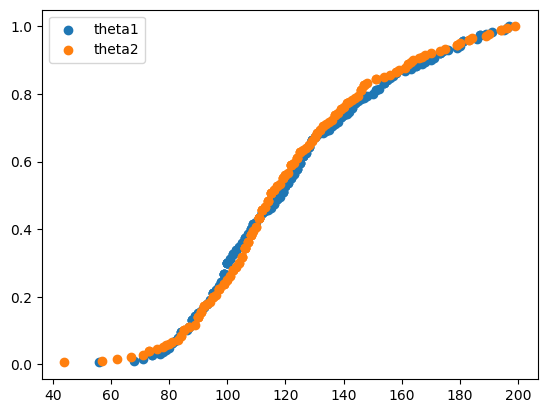

In [104]:
def distr(x, point):
    return np.sum(x <= point) / len(x)
plt.scatter(train_type2['Glucose'], list(map(lambda point: distr(alpha*train_type2['Glucose']**beta, point), alpha*train_type2['Glucose']**beta)), label = 'theta1')
plt.scatter(train_type1['Glucose'], list(map(lambda point: distr(train_type1['Glucose'], point), train_type1['Glucose'])), label = 'theta2')
plt.legend()

In [105]:
def calculate_Kolmogorov_statistic(sample_1, sample_2, alpha, beta):
    y_sample_1 = list(map(lambda point: distr(sample_1, point), alpha * sample_2 ** beta))
    y_sample_2 = list(map(lambda point: distr(alpha * sample_2 ** beta, point), alpha * sample_2 ** beta))
    max_dif = -1e10
    for y_1 in y_sample_1:
        for y_2 in y_sample_2:
            if np.abs(y_1 - y_2) > max_dif:
                max_dif = np.abs(y_1 - y_2)
    return max_dif * np.sqrt(len(sample_1))

In [106]:
kolmogorov_stat = calculate_Kolmogorov_statistic(train_type1['Glucose'], train_type2['Glucose'], alpha, beta)
alpha = 0.05   # 5%
K_alpha = np.sqrt(-1/2 * np.log((1 - alpha) / 2))
print(f"Статистика Колмогорова: {kolmogorov_stat}")
print(f"K_alpha: {K_alpha}")

Статистика Колмогорова: 13.341872265748746
K_alpha: 0.6100985473460397


In [17]:
def z_filter(data, columns, alpha = 2):
    result = data.copy()
    for column in columns:
        result = result[abs((result[column] - result[column].mean())/result[column].std()) < alpha]
    return result

In [21]:
df_unique.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


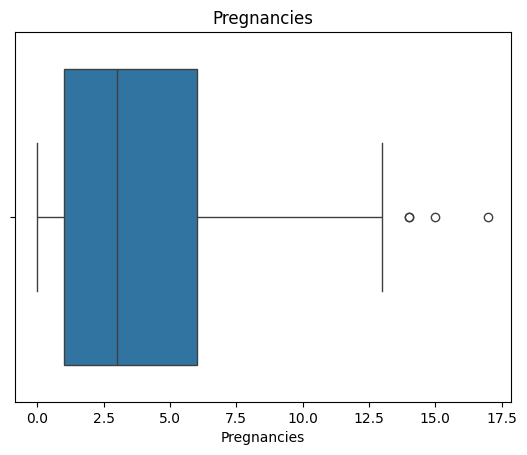

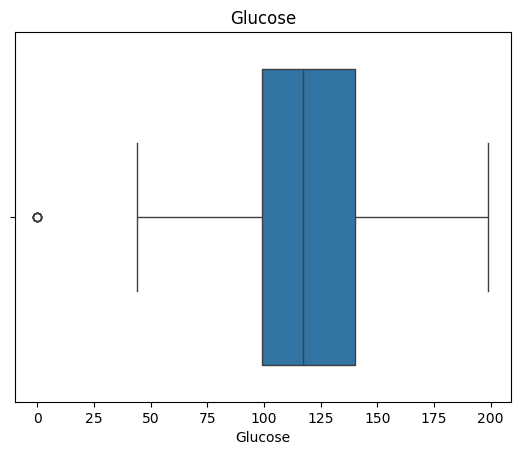

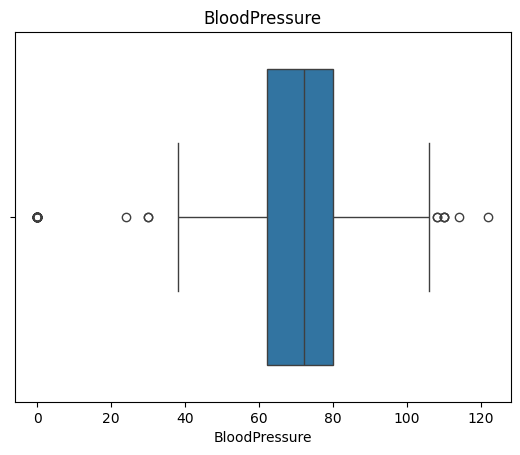

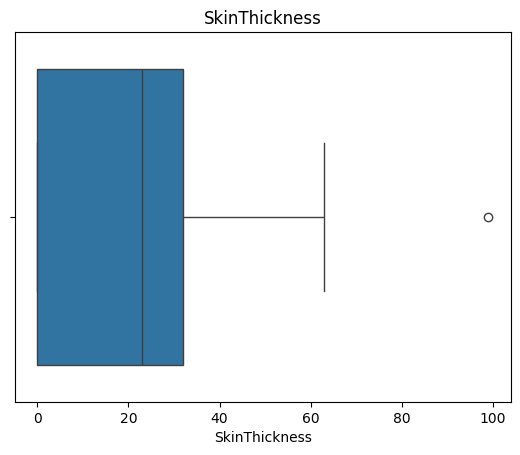

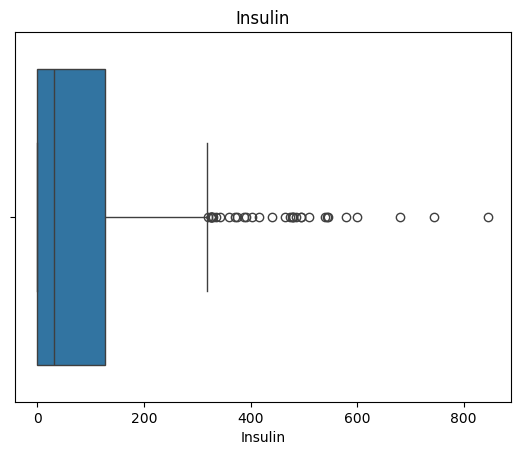

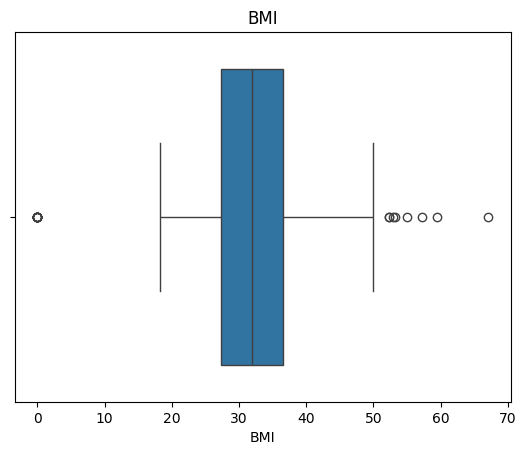

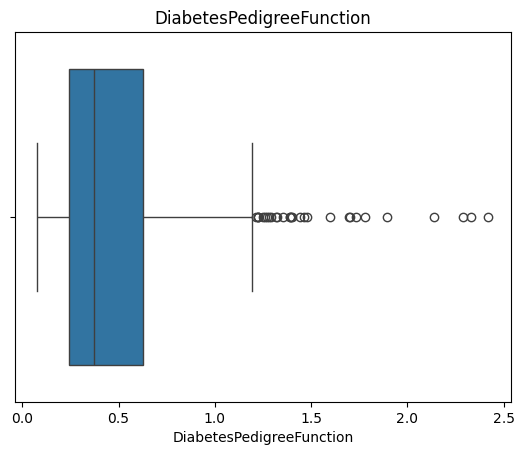

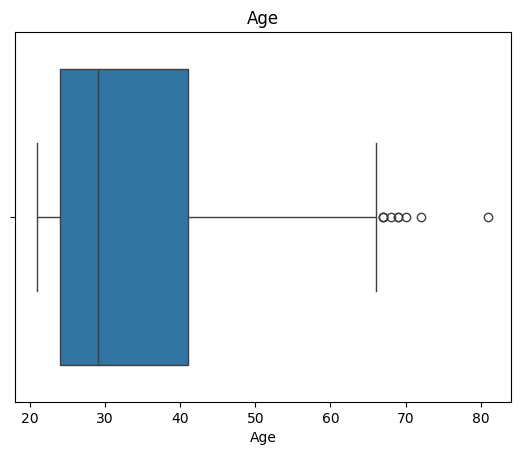

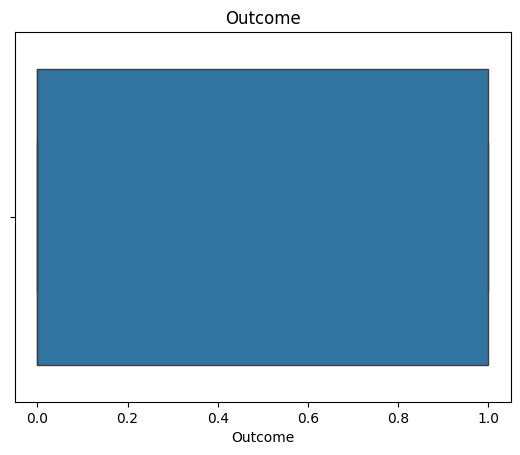

In [54]:
numeric_cols = df_unique.select_dtypes(include=['float64', 'int64']).columns

for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df_unique[col])
    plt.title(col)
    plt.show()

In [57]:
groupe_first_type = df_unique[df_unique["Insulin"] == 0]
groupe_first_type = groupe_first_type.drop("Insulin", axis=1)
groupe_second_type = df_unique[df_unique["Insulin"] != 0]

groupe_first_type = z_filter(groupe_first_type, ['SkinThickness', 'Glucose', 'Pregnancies', 'BMI', 'Age'], alpha = 3)
groupe_second_type = z_filter(groupe_second_type, ['SkinThickness', 'Glucose', 'Pregnancies', 'BMI', 'Age'], alpha = 3)

print(len(groupe_first_type))
print(len(groupe_second_type))

359
380


In [72]:

healthy_second_groupe = groupe_second_type[groupe_second_type["Outcome"] == 1]
ill_second_groupe = groupe_second_type[groupe_second_type["Outcome"] == 0]
print(len(healthy_second_groupe))
print(len(ill_second_groupe))

123
257


In [58]:
corr_all = df_unique.corr()
corr_first_type = groupe_first_type.corr()
corr_second_type = groupe_second_type.corr()

Text(0.5, 1.0, 'Матрица корреляций для группы с нулевым показателем инсулина')

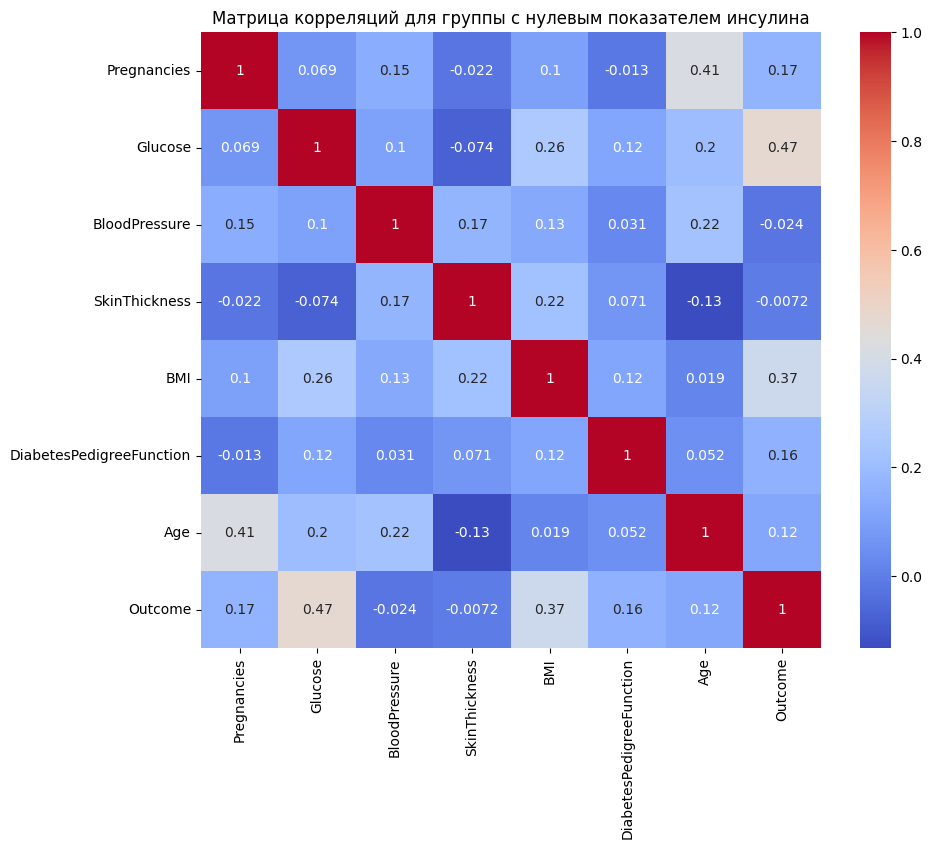

In [59]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_first_type, annot=True, cmap='coolwarm')
plt.title("Матрица корреляций для группы с нулевым показателем инсулина")

Text(0.5, 1.0, 'Матрица корреляций для группы с не нулевым показателем инсулина')

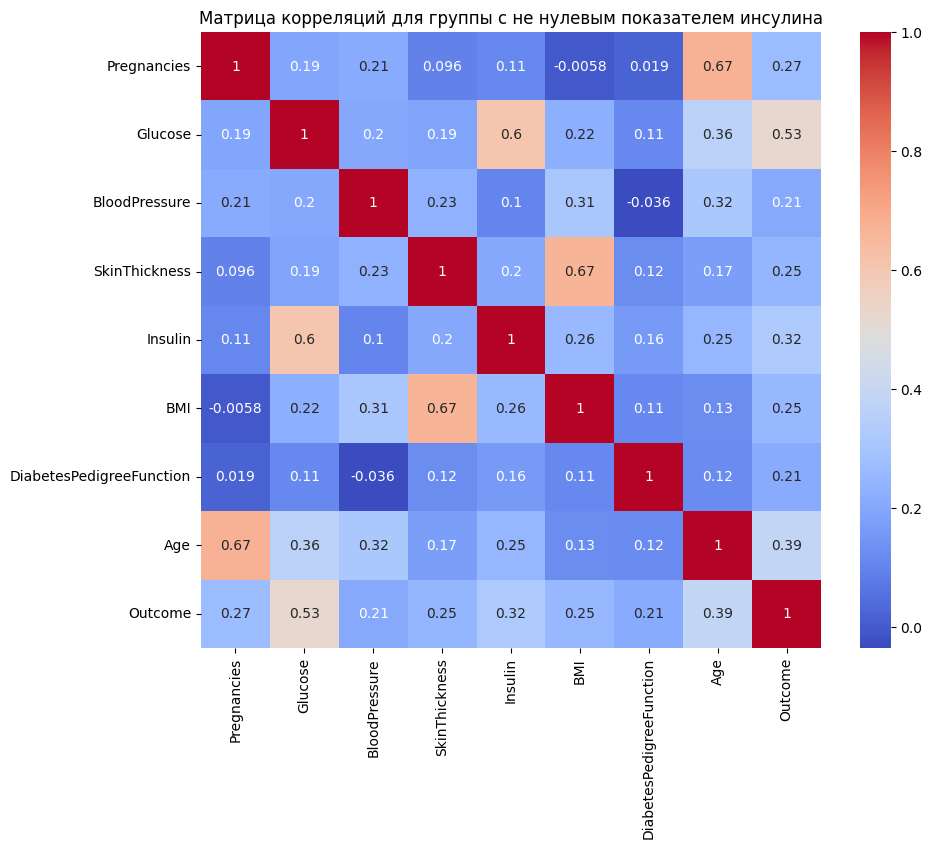

In [60]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_second_type, annot=True, cmap='coolwarm')
plt.title("Матрица корреляций для группы с не нулевым показателем инсулина")

Text(0.5, 1.0, 'Матрица корреляций для всех')

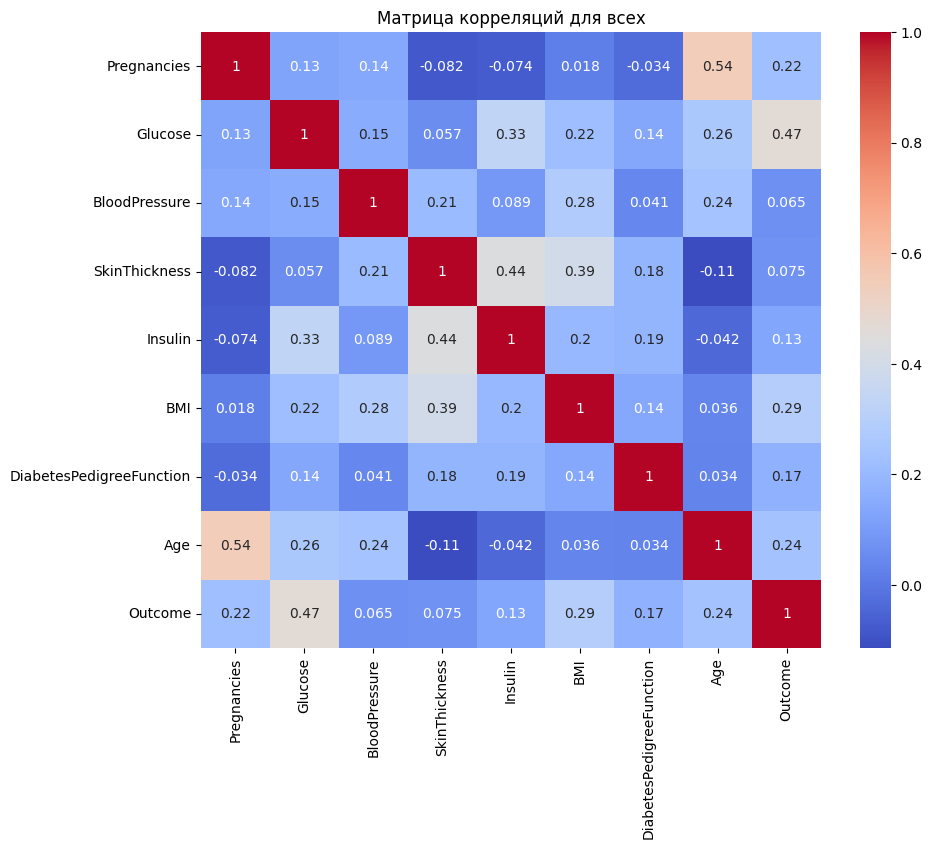

In [61]:
plt.figure(figsize=(10,8))
sns.heatmap(corr_all, annot=True, cmap='coolwarm')
plt.title("Матрица корреляций для всех")

In [116]:
x_first_groupe = groupe_first_type.drop('Outcome', axis=1)
y_first_groupe = groupe_first_type['Outcome']
x_train, x_test, y_train, y_test = train_test_split(x_first_groupe, y_first_groupe, test_size=0.2, random_state=42, stratify=y_first_groupe)

In [112]:
len(x_train) == len(y_train)
len(x_test) == len(y_test)

True

In [117]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
615,3,106,72,0,25.8,0.207,27
21,8,99,84,0,35.4,0.388,50
435,0,141,0,0,42.4,0.205,29
743,9,140,94,0,32.7,0.734,45
250,9,106,52,0,31.2,0.380,42
...,...,...,...,...,...,...,...
677,0,93,60,0,35.3,0.263,25
263,3,142,80,15,32.4,0.200,63
78,0,131,0,0,43.2,0.270,26
299,8,112,72,0,23.6,0.840,58


In [64]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(x_train, y_train)
y_pred_lr = logreg.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.8611111111111112
Confusion Matrix:
 [[40  5]
 [ 5 22]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.89      0.89        45
           1       0.81      0.81      0.81        27

    accuracy                           0.86        72
   macro avg       0.85      0.85      0.85        72
weighted avg       0.86      0.86      0.86        72



In [74]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.7894736842105263
Confusion Matrix:
 [[45  6]
 [10 15]]
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85        51
           1       0.71      0.60      0.65        25

    accuracy                           0.79        76
   macro avg       0.77      0.74      0.75        76
weighted avg       0.78      0.79      0.78        76



In [100]:
svc = SVC(random_state=42)
svc.fit(x_train, y_train)
y_pred_svc = svc.predict(x_test)
print("=== SVM (Support Vector Classifier) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))
print("Classification Report:\n", classification_report(y_test, y_pred_svc))

=== SVM (Support Vector Classifier) ===
Accuracy: 0.75
Confusion Matrix:
 [[46  5]
 [14 11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.90      0.83        51
           1       0.69      0.44      0.54        25

    accuracy                           0.75        76
   macro avg       0.73      0.67      0.68        76
weighted avg       0.74      0.75      0.73        76



In [118]:
x_second_groupe = groupe_second_type.drop(['Outcome', 'Insulin'], axis=1)  
y_second_groupe = groupe_second_type['Outcome']
x_train, x_test, y_train, y_test = train_test_split(x_second_groupe, y_second_groupe, test_size=0.2, random_state=42, stratify=y_second_groupe)
smote = SMOTE(random_state=42)
x_resampled, y_resampled = smote.fit_resample(x_train, y_train)

In [96]:
len(x_train) == len(y_train)
len(x_test) == len(y_test)
len(x_resampled) == len(y_resampled)

True

In [119]:
x_train

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age
203,2,99,70,16,20.4,0.235,27
259,11,155,76,28,33.3,1.353,51
328,2,102,86,36,45.5,0.127,23
588,3,176,86,27,33.3,1.154,52
392,1,131,64,14,23.7,0.389,21
...,...,...,...,...,...,...,...
393,4,116,72,12,22.1,0.463,37
345,8,126,88,36,38.5,0.349,49
663,9,145,80,46,37.9,0.637,40
612,7,168,88,42,38.2,0.787,40


In [120]:
logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(x_train, y_train)
y_pred_lr = logreg.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))


logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(x_resampled, y_resampled)
y_pred_lr = logreg.predict(x_test)
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("Classification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.8157894736842105
Confusion Matrix:
 [[44  7]
 [ 7 18]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.86      0.86        51
           1       0.72      0.72      0.72        25

    accuracy                           0.82        76
   macro avg       0.79      0.79      0.79        76
weighted avg       0.82      0.82      0.82        76

Accuracy: 0.7236842105263158
Confusion Matrix:
 [[37 14]
 [ 7 18]]
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.73      0.78        51
           1       0.56      0.72      0.63        25

    accuracy                           0.72        76
   macro avg       0.70      0.72      0.71        76
weighted avg       0.75      0.72      0.73        76



In [121]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_resampled, y_resampled)
y_pred_rf = rf.predict(x_test)
print("=== Random Forest ===")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("Classification Report:\n", classification_report(y_test, y_pred_rf))

=== Random Forest ===
Accuracy: 0.7105263157894737
Confusion Matrix:
 [[43  8]
 [14 11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.84      0.80        51
           1       0.58      0.44      0.50        25

    accuracy                           0.71        76
   macro avg       0.67      0.64      0.65        76
weighted avg       0.70      0.71      0.70        76

=== Random Forest ===
Accuracy: 0.7894736842105263
Confusion Matrix:
 [[42  9]
 [ 7 18]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.82      0.84        51
           1       0.67      0.72      0.69        25

    accuracy                           0.79        76
   macro avg       0.76      0.77      0.77        76
weighted avg       0.79      0.79      0.79        76



In [122]:
svc = SVC(random_state=42)
svc.fit(x_train, y_train)
y_pred_svc = svc.predict(x_test)
print("=== SVM (Support Vector Classifier) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))
print("Classification Report:\n", classification_report(y_test, y_pred_svc))

svc = SVC(random_state=42)
svc.fit(x_resampled, y_resampled)
y_pred_svc = svc.predict(x_test)
print("=== SVM (Support Vector Classifier) ===")
print("Accuracy:", accuracy_score(y_test, y_pred_svc))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svc))
print("Classification Report:\n", classification_report(y_test, y_pred_svc))

=== SVM (Support Vector Classifier) ===
Accuracy: 0.75
Confusion Matrix:
 [[46  5]
 [14 11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.90      0.83        51
           1       0.69      0.44      0.54        25

    accuracy                           0.75        76
   macro avg       0.73      0.67      0.68        76
weighted avg       0.74      0.75      0.73        76

=== SVM (Support Vector Classifier) ===
Accuracy: 0.8289473684210527
Confusion Matrix:
 [[44  7]
 [ 6 19]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.86      0.87        51
           1       0.73      0.76      0.75        25

    accuracy                           0.83        76
   macro avg       0.81      0.81      0.81        76
weighted avg       0.83      0.83      0.83        76

